# Module 11 Challenge
## Deliverable 2: Scrape and Analyze Mars Weather Data

In [77]:
# Import relevant libraries
from splinter import Browser
from bs4 import BeautifulSoup as soup
import matplotlib.pyplot as plt
import pandas as pd

In [78]:
browser = Browser('chrome')

### Step 1: Visit the Website

Use automated browsing to visit the [Mars Temperature Data Site](https://static.bc-edx.com/data/web/mars_facts/temperature.html). Inspect the page to identify which elements to scrape.

   > **Hint** To identify which elements to scrape, you might want to inspect the page by using Chrome DevTools to discover whether the table contains usable classes.


In [79]:
# Visit the website
# https://static.bc-edx.com/data/web/mars_facts/temperature.html
url = "https://static.bc-edx.com/data/web/mars_facts/temperature.html"
browser.visit(url)

### Step 2: Scrape the Table

Create a Beautiful Soup object and use it to scrape the data in the HTML table.

Note that this can also be achieved by using the Pandas `read_html` function. However, use Beautiful Soup here to continue sharpening your web scraping skills.

In [80]:
# Gather the html from the current page in the browser
html = browser.html

# Create a Beautiful Soup Object
soup = soup(html, 'html.parser')

In [81]:
# Extract all rows of data (see below)

# Find the table
table = soup.find('table')

# Extract the rows
data = []

for row in table.find_all('tr'):  # Loop through all table rows
    cols = row.find_all('td')  # Find all cells in the row
    cols = [ele.text.strip() for ele in cols]  # Get text and strip whitespace
    if cols:  # Only add rows that have data
        data.append(cols)

# Now `data` contains all rows of scraped data from the table
print(data)


[['2', '2012-08-16', '10', '155', '6', '-75.0', '739.0'], ['13', '2012-08-17', '11', '156', '6', '-76.0', '740.0'], ['24', '2012-08-18', '12', '156', '6', '-76.0', '741.0'], ['35', '2012-08-19', '13', '157', '6', '-74.0', '732.0'], ['46', '2012-08-20', '14', '157', '6', '-74.0', '740.0'], ['57', '2012-08-21', '15', '158', '6', '-78.0', '740.0'], ['68', '2012-08-22', '16', '158', '6', '-77.0', '740.0'], ['79', '2012-08-23', '17', '159', '6', '-76.0', '742.0'], ['112', '2012-08-27', '21', '161', '6', '-74.0', '741.0'], ['114', '2012-08-28', '22', '162', '6', '-74.0', '742.0'], ['123', '2012-08-29', '23', '162', '6', '-75.0', '741.0'], ['134', '2012-08-30', '24', '163', '6', '-75.0', '742.0'], ['145', '2012-08-31', '25', '163', '6', '-75.0', '743.0'], ['156', '2012-09-01', '26', '164', '6', '-76.0', '745.0'], ['163', '2012-09-02', '27', '164', '6', '-75.0', '743.0'], ['170', '2012-09-03', '28', '165', '6', '-75.0', '745.0'], ['171', '2012-09-04', '29', '166', '6', '-75.0', '747.0'], ['172

### Step 3: Store the Data

Assemble the scraped data into a Pandas DataFrame. The columns should have the same headings as the table on the website. Here’s an explanation of the column headings:

* `id`: the identification number of a single transmission from the Curiosity rover
* `terrestrial_date`: the date on Earth
* `sol`: the number of elapsed sols (Martian days) since Curiosity landed on Mars
* `ls`: the solar longitude
* `month`: the Martian month
* `min_temp`: the minimum temperature, in Celsius, of a single Martian day (sol)
* `pressure`: The atmospheric pressure at Curiosity's location

In [82]:
# Create an empty list
mars_list = []

# Define the column names
columns = ['id', 'terrestrial_date', 'sol', 'ls', 'month', 'min_temp', 'pressure']


In [83]:
# Create a Pandas DataFrame by using the list of rows and a list of the column names
from IPython.display import display, Markdown

# Create a DataFrame from the scraped data
mars_df = pd.DataFrame(data, columns=columns)

# Display the DataFrame
display(Markdown("## Mars DataFrame - First 5 Rows"))
print("-" * 30)  # Print a line under the header

# Display the first 5 rows of the DataFrame
display(mars_df.head(5))

## Mars DataFrame - First 5 Rows

------------------------------


,id,terrestrial_date,sol,ls,month,min_temp,pressure
0,2,2012-08-16,10,155,6,-75.0,739.0
1,13,2012-08-17,11,156,6,-76.0,740.0
2,24,2012-08-18,12,156,6,-76.0,741.0
3,35,2012-08-19,13,157,6,-74.0,732.0
4,46,2012-08-20,14,157,6,-74.0,740.0


### Step 4: Prepare Data for Analysis

Examine the data types that are currently associated with each column. If necessary, cast (or convert) the data to the appropriate `datetime`, `int`, or `float` data types.

  > **Hint** You can use the Pandas `astype` and `to_datetime` methods to accomplish this task.


In [84]:
# Examine data type of each column
data_types = mars_df.dtypes
# Display the data types
print(data_types)

id                  object
terrestrial_date    object
sol                 object
ls                  object
month               object
min_temp            object
pressure            object
dtype: object


In [85]:
# Change data types for data analysis

# Convert 'terrestrial_date' to datetime
mars_df['terrestrial_date'] = pd.to_datetime(mars_df['terrestrial_date'])

# Convert 'sol', 'ls', and 'month' to integers
mars_df['sol'] = mars_df['sol'].astype(int)
mars_df['ls'] = mars_df['ls'].astype(int)
mars_df['month'] = mars_df['month'].astype(int)

# Convert 'min_temp' and 'pressure' to floats
mars_df['min_temp'] = mars_df['min_temp'].astype(float)
mars_df['pressure'] = mars_df['pressure'].astype(float)


In [86]:
# Confirm type changes were successful by examining data types again
print(mars_df.dtypes)

id                          object
terrestrial_date    datetime64[ns]
sol                          int64
ls                           int64
month                        int64
min_temp                   float64
pressure                   float64
dtype: object


### Step 5: Analyze the Data

Analyze your dataset by using Pandas functions to answer the following questions:

1. How many months exist on Mars?
2. How many Martian (and not Earth) days worth of data exist in the scraped dataset?
3. What are the coldest and the warmest months on Mars (at the location of Curiosity)? To answer this question:
    * Find the average the minimum daily temperature for all of the months.
    * Plot the results as a bar chart.
4. Which months have the lowest and the highest atmospheric pressure on Mars? To answer this question:
    * Find the average the daily atmospheric pressure of all the months.
    * Plot the results as a bar chart.
5. About how many terrestrial (Earth) days exist in a Martian year? To answer this question:
    * Consider how many days elapse on Earth in the time that Mars circles the Sun once.
    * Visually estimate the result by plotting the daily minimum temperature.


In [87]:
# 1. How many months are there on Mars?
month_counts = mars_df['month'].value_counts().sort_index()

# Display the result
print(month_counts)

month
1     174
2     178
3     192
4     194
5     149
6     147
7     142
8     141
9     134
10    112
11    138
12    166
Name: count, dtype: int64


In [88]:
# 2. How many Martian days' worth of data are there?
num_sols = mars_df['sol'].nunique()

# Display the result
print(num_sols)

1867


In [89]:
# 3. What is the average low temperature by month?
average_low_temp = mars_df.groupby('month')['min_temp'].mean()

# Display the result
print(average_low_temp)

month
1    -77.160920
2    -79.932584
3    -83.307292
4    -82.747423
5    -79.308725
6    -75.299320
7    -72.281690
8    -68.382979
9    -69.171642
10   -71.982143
11   -71.985507
12   -74.451807
Name: min_temp, dtype: float64


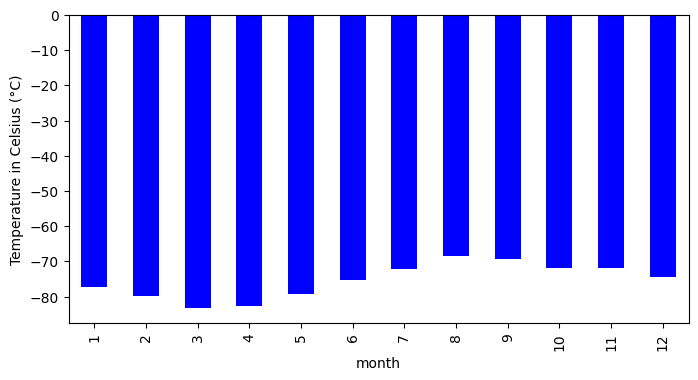

In [90]:
# Plot the average temperature by month

average_low_temp = mars_df.groupby('month')['min_temp'].mean()

# Create a bar chart
plt.figure(figsize=(8, 4))
average_low_temp.plot(kind='bar', color='blue')

# Add titles and labels

plt.xlabel('month', fontsize=10)
plt.ylabel('Temperature in Celsius (°C)', fontsize=10)
plt.xticks(rotation=90)  # Rotate x-axis labels to horizontal

# Display
plt.show()

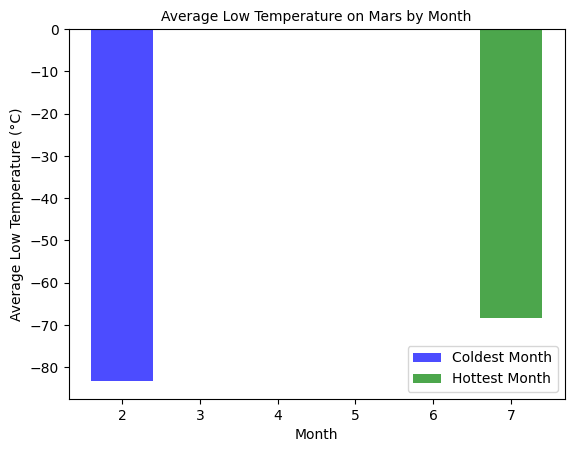

In [91]:
# Identify the coldest and hottest months in Curiosity's location

# Calculate the average low temperature by month
average_low_temp = mars_df.groupby('month')['min_temp'].mean()

# Identify the coldest and hottest months
coldest_month = average_low_temp.idxmin()
coldest_temp = average_low_temp.min()
hottest_month = average_low_temp.idxmax()
hottest_temp = average_low_temp.max()

# Create a bar chart

# Highlight the coldest month
plt.bar(coldest_month - 1, coldest_temp, color='blue', label='Coldest Month', alpha=0.7)
# Highlight the hottest month
plt.bar(hottest_month - 1, hottest_temp, color='green', label='Hottest Month', alpha=0.7)

# Add titles and labels
plt.title('Average Low Temperature on Mars by Month', fontsize=10)
plt.xlabel('Month', fontsize=10)
plt.ylabel('Average Low Temperature (°C)', fontsize=10)
plt.xticks(rotation=0)  # Rotate x-axis labels to horizontal
plt.legend()

# Show the plot

plt.show()

In [92]:
# 4. Average pressure by Martian month
average_pressure = mars_df.groupby('month')['pressure'].mean()

# Display the result
print(average_pressure)

month
1     862.488506
2     889.455056
3     877.322917
4     806.329897
5     748.557047
6     745.054422
7     795.105634
8     873.829787
9     913.305970
10    887.312500
11    857.014493
12    842.156627
Name: pressure, dtype: float64


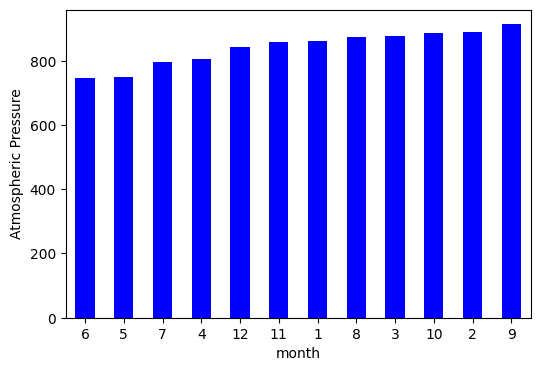

In [93]:
# sort the average pressure by month
average_pressure = mars_df.groupby('month')['pressure'].mean()

# Sort the average pressure values in ascending order
average_pressure_sorted = average_pressure.sort_values()

# Create a bar chart
plt.figure(figsize=(6, 4))
average_pressure_sorted.plot(kind='bar', color='blue')

plt.xlabel('month')
plt.ylabel('Atmospheric Pressure')
plt.xticks(rotation=0)  # Rotate x-axis labels if needed


# Show the plot
plt.show()

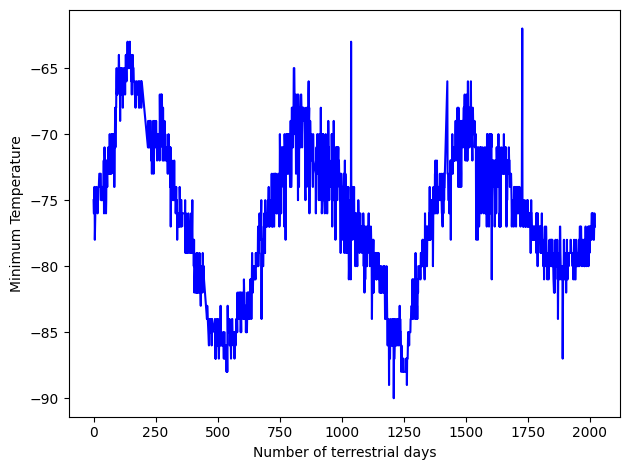

In [94]:
# 5. How many terrestrial (earth) days are there in a Martian year?

mars_df["daysStart"] = (mars_df["terrestrial_date"] - mars_df["terrestrial_date"].min()).dt.days
plt.plot(mars_df["daysStart"], mars_df["min_temp"], color='blue', label="Min Temperature")
plt.xlabel("Number of terrestrial days")
plt.ylabel("Minimum Temperature")
plt.tight_layout()
plt.show()

On average, the third month has the coldest minimum temperature on Mars, and the eighth month is the warmest. But it is always very cold there in human terms!



Atmospheric pressure is, on average, lowest in the sixth month and highest in the ninth.

The distance from peak to peak is roughly 1425-750, or 675 days. A year on Mars appears to be about 675 days from the plot. Internet search confirms that a Mars year is equivalent to 687 earth days.

### Step 6: Save the Data

Export the DataFrame to a CSV file.

In [95]:
# Write the data to a CSV
output_file = "mars_data.csv"

# Export the DataFrame to a CSV file
mars_df.to_csv(output_file, index=False)


In [96]:
browser.quit()